Sent: 6000, Received: 6000, Drop rate: 0.00%
Inter-arrival mean: 0.003333s, λ̂ ≈ 300.00 pkt/s
Latency mean: 10.780 ms, std: 0.178 ms


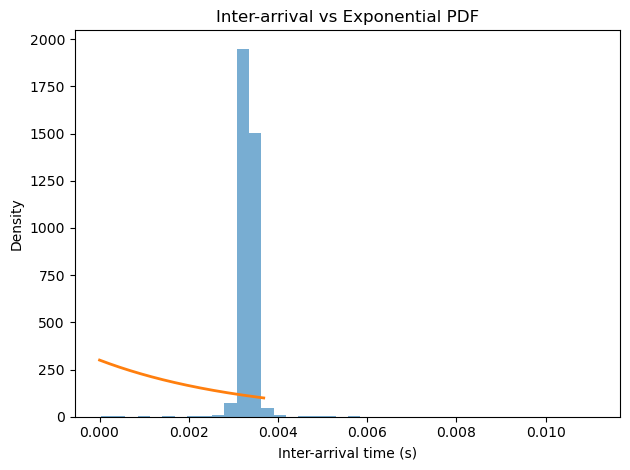

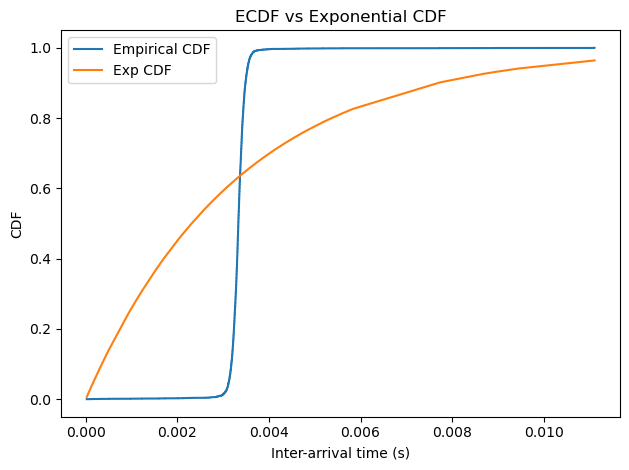

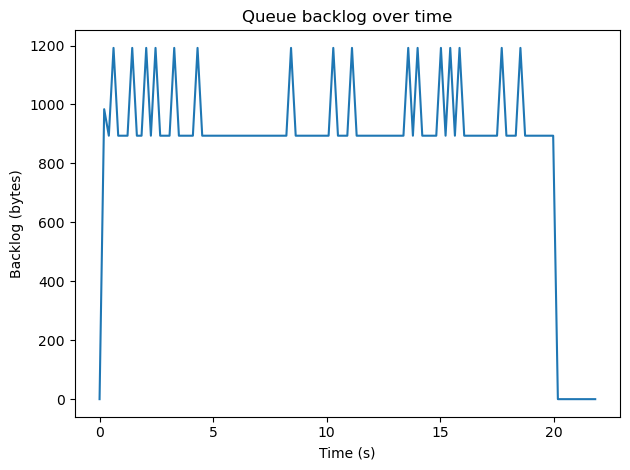

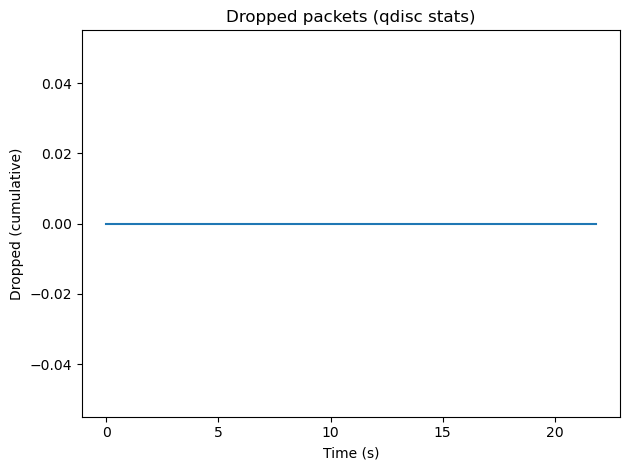

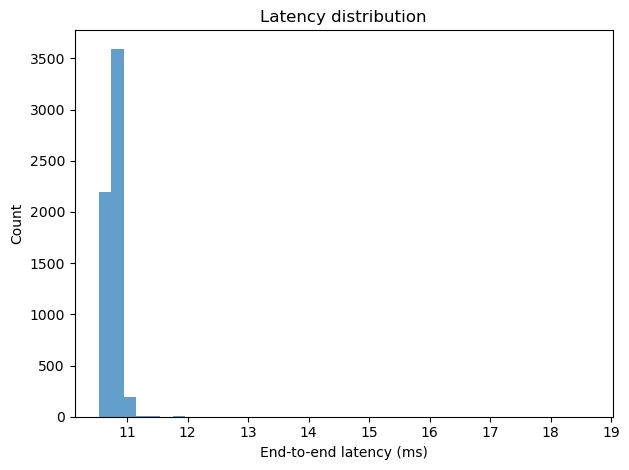

In [1]:
import argparse, os, pandas as pd, numpy as np, matplotlib.pyplot as plt

def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1)/len(xs)
    return xs, ys

def main():
    result_dir = "results"

    send = pd.read_csv(os.path.join(result_dir, "send_log.csv"))
    recv = pd.read_csv(os.path.join(result_dir, "recv_log.csv"))
    qmon = pd.read_csv(os.path.join(result_dir, "queue_log.csv"))

    # Chuyển sang float
    send["t_send"] = send["t_send"].astype(float)
    recv["t_recv"] = recv["t_recv"].astype(float)
    recv["t_send"] = recv["t_send"].astype(float)
    recv["latency_ms"] = recv["latency_ms"].astype(float)

    # Thống kê
    sent = len(send)
    received = len(recv)
    drop_rate = (sent - received) / sent if sent > 0 else 0.0
    ia = np.diff(recv["t_recv"].values)  # inter-arrival
    ia = ia[ia > 0]
    lam_hat = 1.0 / ia.mean() if len(ia) else np.nan
    lat_ms = recv["latency_ms"].values

    print(f"Sent: {sent}, Received: {received}, Drop rate: {drop_rate*100:.2f}%")
    if len(ia):
        print(f"Inter-arrival mean: {ia.mean():.6f}s, λ̂ ≈ {lam_hat:.2f} pkt/s")
    if len(lat_ms):
        print(f"Latency mean: {np.mean(lat_ms):.3f} ms, std: {np.std(lat_ms):.3f} ms")

    # 1) Histogram inter-arrival + PDF mũ
    if len(ia):
        plt.figure()
        plt.hist(ia, bins=40, density=True, alpha=0.6)
        xs = np.linspace(0, np.percentile(ia, 99), 200)
        pdf = lam_hat * np.exp(-lam_hat * xs)
        plt.plot(xs, pdf, linewidth=2)
        plt.xlabel("Inter-arrival time (s)")
        plt.ylabel("Density")
        plt.title("Inter-arrival vs Exponential PDF")
        plt.tight_layout()

        # 2) ECDF vs CDF lý thuyết
        xs_ecdf, ys_ecdf = ecdf(ia)
        plt.figure()
        plt.plot(xs_ecdf, ys_ecdf, drawstyle="steps-post", label="Empirical CDF")
        cdf = 1 - np.exp(-lam_hat * xs_ecdf)
        plt.plot(xs_ecdf, cdf, label="Exp CDF")
        plt.xlabel("Inter-arrival time (s)")
        plt.ylabel("CDF")
        plt.legend()
        plt.title("ECDF vs Exponential CDF")
        plt.tight_layout()

    # 3) Queue backlog/dropped theo thời gian
    if len(qmon):
        t0 = qmon["t"].astype(float).min()
        t_rel = qmon["t"].astype(float) - t0
        plt.figure()
        plt.plot(t_rel, qmon["backlog_bytes"])
        plt.xlabel("Time (s)")
        plt.ylabel("Backlog (bytes)")
        plt.title("Queue backlog over time")
        plt.tight_layout()

        plt.figure()
        plt.plot(t_rel, qmon["dropped_total"])
        plt.xlabel("Time (s)")
        plt.ylabel("Dropped (cumulative)")
        plt.title("Dropped packets (qdisc stats)")
        plt.tight_layout()

    # 4) Histogram độ trễ
    if len(lat_ms):
        plt.figure()
        plt.hist(lat_ms, bins=40, density=False, alpha=0.7)
        plt.xlabel("End-to-end latency (ms)")
        plt.ylabel("Count")
        plt.title("Latency distribution")
        plt.tight_layout()

if __name__ == "__main__":
    main()

